# Van Hateren 圆盘 teacher：选参 × 风险估计
完整 d=10000，n=1000；26 个噪声水平，100 次真实自然图像 ridge MC。
三列：固定 λ、DE 泛化选参、Gaussian distributional accentuation oracle；每列同一正则化下比较 Egen(DE/MC) 与 Eacc(leading DE/distributional DE/MC)。MC 点为 100 次试验的算术 mean（不是 median），误差条为 mean ±2 SE，阴影为 trial 分布的 10–90% 分位区间（不是均值的置信区间）。
原始数据和日志目前保存在下方列出的非 Lustre NFS scratch；STORE_DIR 项目目录是最终归档目的地，尚未回拷。这里仅读取小型汇总表，不重新执行大计算。Gaussian 分布是匹配矩近似，不是完整分布定理。

## 已完成的真实图像实验
100 trials × 26 noise levels × 3 policies；Egen 与 Eacc 在每列同轴比较。下图是保存的结果预览，修改样式请运行后面的绘图单元。
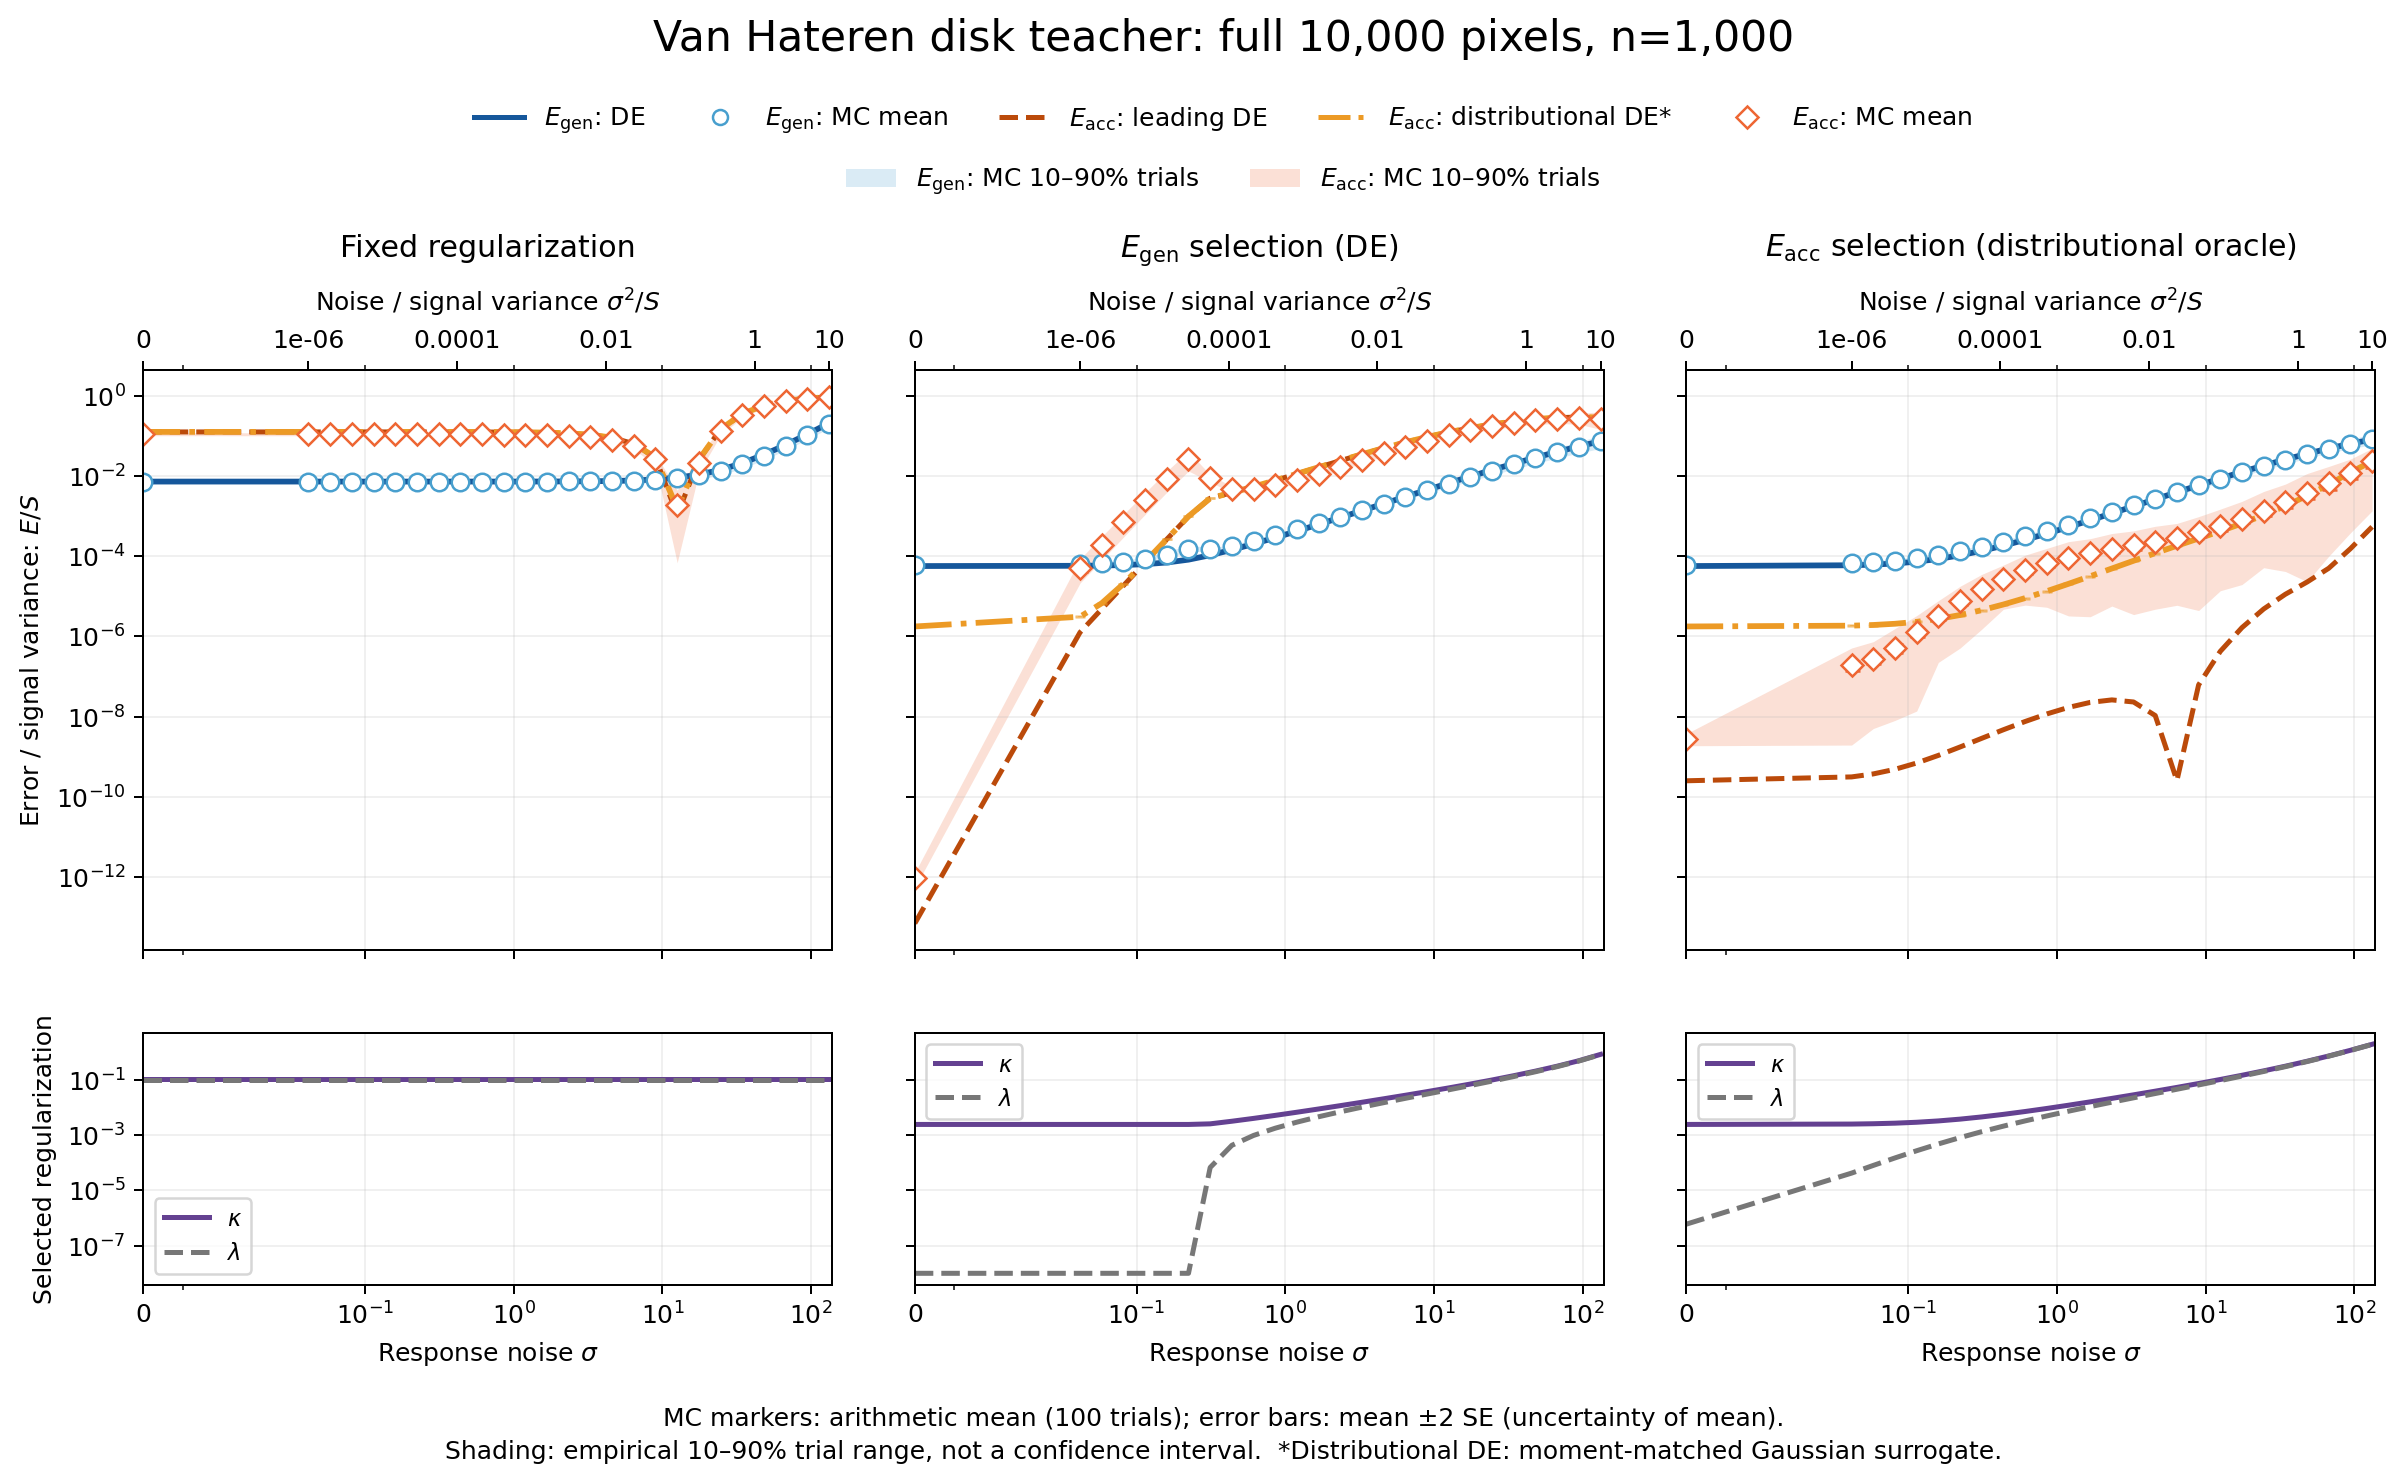
原图来自公开 .iml 镜像，文件名单与旧实验一致。重建后的信号方差与旧谱相对差为 3.24e-7。Gaussian distributional DE 为近似；低噪声偏差仍存在。
非 Lustre 备份：`/n/netscratch/kempner_binxuwang_lab/Everyone/binxuwang/AccentuationPredRMT/vanhateren_selection_estimation_local_20260917/`。Lustre 归档尚未完成。


In [ ]:
from pathlib import Path
import os
os.environ.setdefault('MPLCONFIGDIR','/tmp/accentuationpredrmt-matplotlib')
os.environ.setdefault('XDG_CACHE_HOME','/tmp/accentuationpredrmt-xdg-cache')
import sys
import pandas as pd
import matplotlib.pyplot as plt
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'rmt_core').is_dir())
sys.path.insert(0,str(ROOT))
from scripts.plot_pixel_ridge_estimator_comparison import plot_comparison
OUT=ROOT/'notebooks/outputs/pixel_ridge/vanhateren_selection_estimation'
table=pd.read_csv(OUT/'comparison.csv')
display(table[['policy','sigma','ratio','lam','kappa','E_gen','E_gen_mc','E_acc','acc_distribution','E_acc_mc','trials']])
# Inspect the arithmetic mean, median, standard deviation, SE, and empirical quantiles separately.
display(table[['policy','sigma','E_acc_mc','E_acc_mc_median','E_acc_mc_std','E_acc_mc_se','E_acc_mc_q10','E_acc_mc_q90']])


In [ ]:
fig,axes=plot_comparison(table)
fig.suptitle('Van Hateren disk teacher: full 10,000 pixels, n=1,000',y=1.01,fontsize=17)
fig.savefig(OUT/'selection_vs_estimation.png',dpi=180,bbox_inches='tight')
fig.savefig(OUT/'selection_vs_estimation.pdf',bbox_inches='tight')
plt.show()


## 扩展指标：R² 与 slope
下面 SHOW_SKLEARN_CV 开关控制真实 sklearn RidgeCV 对照，仅在第二列与 DE 泛化选参比较；第一、第三列不添加此序列。点线三角形是逐 trial LOOCV 选参结果，第二列底行绿色为其 lambda median / 10–90% trial 区间。PDF 使用嵌入 TrueType 矢量字体，同时导出 PNG。
四行依次为 E/S、R²、true-on-fitted slope、κ/λ。三列选参不变；蓝色 gen，橙色 acc；DE 实线、leading acc 虚线、Gaussian surrogate 点划线、MC 空心点。
R²_gen=1−E_gen/S；slope_gen=βᵀΣβhat/(βhatᵀΣβhat)；slope_acc=N/D；R²_acc=1−(D/N−1)²。MC 与 Gaussian 的非线性指标逐样本计算后再平均。
注意：Gaussian R²_acc 曲线是 8192 draws 的有限抽样均值。N 接近零时逆比值有重尾；不保证总体期望存在或抽样均值收敛，不能将其当作稳定的 distributional DE 定理。
![Extended comparison](outputs/pixel_ridge/vanhateren_selection_estimation/selection_vs_estimation_extended.png)


In [ ]:
from scripts.extend_vanhateren_evaluations import plot as plot_extended
extended = pd.read_csv(OUT/'comparison_extended.csv')
SHOW_SKLEARN_CV = True  # False: reproduce original DE-selected-policy comparison
sklearn_cv = pd.read_csv(OUT/'sklearn_cv_summary.csv') if SHOW_SKLEARN_CV else None
SHOW_STATIONARY = True  # paper interior optimum; no extrapolation to boundary solutions
EXTRAPOLATE_STATIONARY = True  # directly substitute boundary kappa; not a stationary solution
stationary_file = 'stationary_cv_extrapolated.csv' if EXTRAPOLATE_STATIONARY else 'stationary_cv.csv'
stationary = pd.read_csv(OUT/stationary_file) if SHOW_STATIONARY else None
fig = plot_extended(extended, sklearn_cv=sklearn_cv, show_sklearn_cv=SHOW_SKLEARN_CV, stationary=stationary)
suffix = '_with_sklearn_cv' if SHOW_SKLEARN_CV else ''
suffix += '_stationary' if SHOW_STATIONARY else ''
suffix += '_extrapolated' if SHOW_STATIONARY and EXTRAPOLATE_STATIONARY else ''
fig.savefig(OUT/f'selection_vs_estimation_extended{suffix}.png', dpi=160, bbox_inches='tight')
fig.savefig(OUT/f'selection_vs_estimation_extended{suffix}.pdf', bbox_inches='tight')
plt.show()
